# **IMPORTING LIABRARIES**

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# **IMPORTING DATASET**

In [3]:
from google.colab import files

uploaded = files.upload()

Saving part_3_customer_churn_prediction.xlsx to part_3_customer_churn_prediction.xlsx


In [5]:
df=pd.read_excel('part_3_customer_churn_prediction.xlsx')

# **UNDERSTANDING DATASET**

In [6]:
# displaying first 5 rows of the dataset
df.head()

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,TEL00001,Male,0,Yes,No,42,Yes,Yes,Fiber optic,Yes,...,No,No,No,Yes,One year,Yes,Electronic check,102.95,4306.99,No
1,TEL00002,Female,0,No,Yes,55,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,Yes,One year,No,Credit card,120.39,6588.83,No
2,TEL00003,Female,0,Yes,Yes,0,Yes,No,DSL,No,...,Yes,No,No,Yes,Two year,No,Mailed check,74.42,0.00,Yes
3,TEL00004,Female,0,No,Yes,16,Yes,Yes,DSL,No,...,Yes,Yes,No,Yes,Month-to-month,No,Mailed check,83.24,1324.06,No
4,TEL00005,Male,0,Yes,No,6,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,25.44,123.68,Yes


In [7]:
# displaying information of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        1800 non-null   object 
 1   Gender            1800 non-null   object 
 2   SeniorCitizen     1800 non-null   int64  
 3   Partner           1800 non-null   object 
 4   Dependents        1800 non-null   object 
 5   Tenure            1800 non-null   int64  
 6   PhoneService      1800 non-null   object 
 7   MultipleLines     1800 non-null   object 
 8   InternetService   1800 non-null   object 
 9   OnlineSecurity    1800 non-null   object 
 10  OnlineBackup      1800 non-null   object 
 11  DeviceProtection  1800 non-null   object 
 12  TechSupport       1800 non-null   object 
 13  StreamingTV       1800 non-null   object 
 14  StreamingMovies   1800 non-null   object 
 15  Contract          1800 non-null   object 
 16  PaperlessBilling  1800 non-null   object 


In [8]:
# displaying shape of data
df.shape

(1800, 21)

In [9]:
# displaying column names
df.columns

Index(['CustomerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'Tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
# Displaying statistical summary of the data
df.describe()

,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
count,1800.000000,1800.000000,1800.000000,1769.000000
mean,0.162778,22.603889,74.462250,1699.169503
std,0.369265,20.165802,31.532909,1780.084580
min,0.000000,0.000000,18.000000,0.000000
25%,0.000000,6.000000,53.150000,383.650000
50%,0.000000,16.000000,79.665000,1077.400000
75%,0.000000,33.000000,98.567500,2436.040000
max,1.000000,72.000000,139.460000,10040.700000


# **DATA CLEANING AND PREPROCESSING**

In [11]:
# CHECKING NULLS OR EMPTY ROWS
df.isnull().sum()

,0
CustomerID,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [12]:
# replacing nulls with median of total charges
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [13]:
# checking datatypes
df.dtypes

,0
CustomerID,object
Gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
Tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [15]:
# droping customer ID
df.drop('CustomerID', axis=1, inplace=True)

**Encoding Categorical Variables**

In [16]:
# Converting datatype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [17]:
# Encoding Categorical Variables
binary_columns = [
    'Gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

# Replace values
for col in binary_columns:
    df[col] = df[col].replace({
        'Yes': 1,
        'No': 0,
        'Male': 1,
        'Female': 0
    })

In [18]:
# performing hot encoding for the remaining varibales
df = pd.get_dummies(df, drop_first=True)

In [19]:
# varify all columns are Numeric
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 31 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Gender                                1800 non-null   int64  
 1   Partner                               1800 non-null   int64  
 2   Dependents                            1800 non-null   int64  
 3   Tenure                                1800 non-null   int64  
 4   PhoneService                          1800 non-null   int64  
 5   PaperlessBilling                      1800 non-null   int64  
 6   MonthlyCharges                        1800 non-null   float64
 7   TotalCharges                          1800 non-null   float64
 8   Churn                                 1800 non-null   int64  
 9   SeniorCitizen_1                       1800 non-null   bool   
 10  MultipleLines_No phone service        1800 non-null   bool   
 11  MultipleLines_Yes

In [22]:
# converting boolean into numeric
bool_columns = df.select_dtypes(include='bool').columns

df[bool_columns] = df[bool_columns].astype(int)

In [23]:
# displaying first five rows of dataset
df.head()

,Gender,Partner,Dependents,Tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,SeniorCitizen_1,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,1,0,42,1,1,102.95,4306.99,0,0,...,0,0,0,0,1,1,0,0,1,0
1,0,0,1,55,1,0,120.39,6588.83,0,0,...,1,0,0,0,1,1,0,1,0,0
2,0,1,1,0,1,0,74.42,0.00,1,0,...,0,0,0,0,1,0,1,0,0,1
3,0,0,1,16,1,0,83.24,1324.06,0,0,...,1,0,0,0,1,0,0,0,0,1
4,1,1,0,6,1,1,25.44,123.68,1,0,...,0,1,0,1,0,0,0,0,1,0


Scaling numeric variables

In [25]:
#separating feature and target
# Features
X = df.drop('Churn', axis=1)

# Target variable
y = df['Churn']

In [26]:
#Select Numeric Columns for Scaling
numeric_columns = ['Tenure', 'MonthlyCharges', 'TotalCharges']

In [27]:
# Apply Standard Scaling
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Scale selected columns
X[numeric_columns] = scaler.fit_transform(X[numeric_columns])

In [28]:
#Check scaled data
X.head()

,Gender,Partner,Dependents,Tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,SeniorCitizen_1,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,1,0,0.962099,1,1,0.903680,1.482709,0,0,...,0,0,0,0,1,1,0,0,1,0
1,0,0,1,1.606934,1,0,1.456907,2.774771,0,0,...,1,0,0,0,1,1,0,1,0,0
2,0,1,1,-1.121214,1,0,-0.001340,-0.956070,0,0,...,0,0,0,0,1,0,1,0,0,1
3,0,0,1,-0.327571,1,0,0.278445,-0.206338,0,0,...,1,0,0,0,1,0,0,0,0,1
4,1,1,0,-0.823597,1,1,-1.555070,-0.886037,0,0,...,0,1,0,1,0,0,0,0,1,0


**Spliting dataset into training and testing sets**

In [29]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1440, 30)
X_test shape: (360, 30)
y_train shape: (1440,)
y_test shape: (360,)


# **EXPLORATORY DATA ANALYSIS**

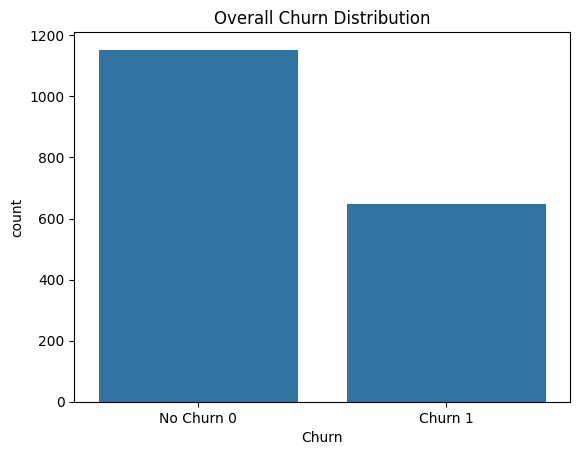

In [49]:
# overall churn rate
sns.countplot(x='Churn', data=df)
plt.title('Overall Churn Distribution')
plt.xticks([0, 1], ['No Churn 0', 'Churn 1']) # Add labels to the x-axis
plt.show()

The chart shows the proportion of customers who stayed versus customers who left. A high churn rate indicates customer retention issues.

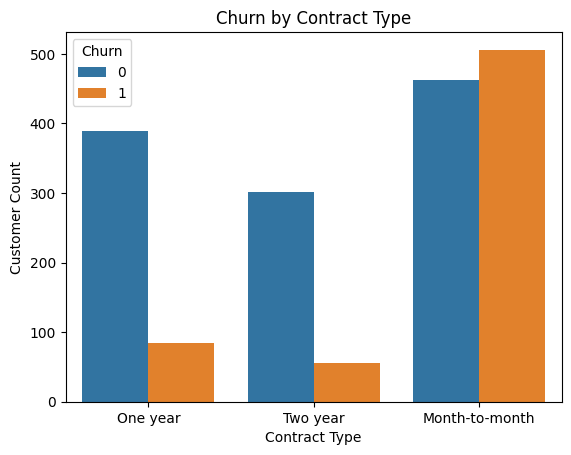

In [32]:
# churn by contract type

# Reconstruct the 'Contract' column for plotting
def get_original_contract_type(row):
    if row['Contract_One year'] == 1:
        return 'One year'
    elif row['Contract_Two year'] == 1:
        return 'Two year'
    else:
        return 'Month-to-month'

df['Original_Contract'] = df.apply(get_original_contract_type, axis=1)

sns.countplot(x='Original_Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Customer Count')
plt.show()

# Drop the temporary 'Original_Contract' column if not needed further
df.drop('Original_Contract', axis=1, inplace=True)

Customers with month-to-month contracts are more likely to churn compared to yearly contract customers.

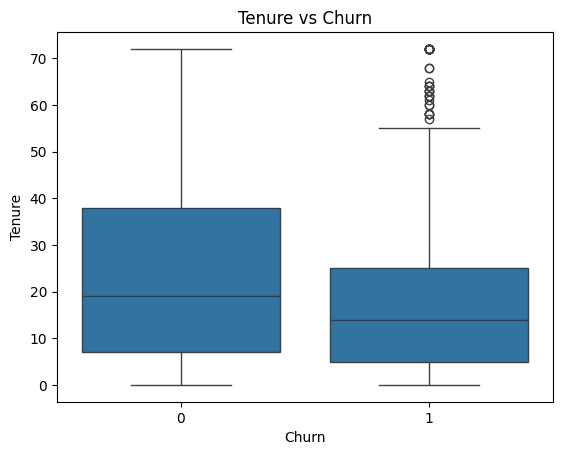

In [34]:
# churn by tenure
sns.boxplot(x='Churn', y='Tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

Customers with shorter tenure tend to churn more frequently.

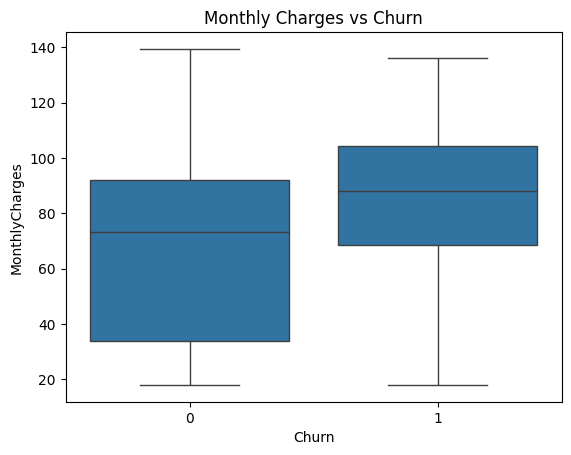

In [35]:
# churn by monthly charges
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

Customers with high monthly charges show higher churn probability.

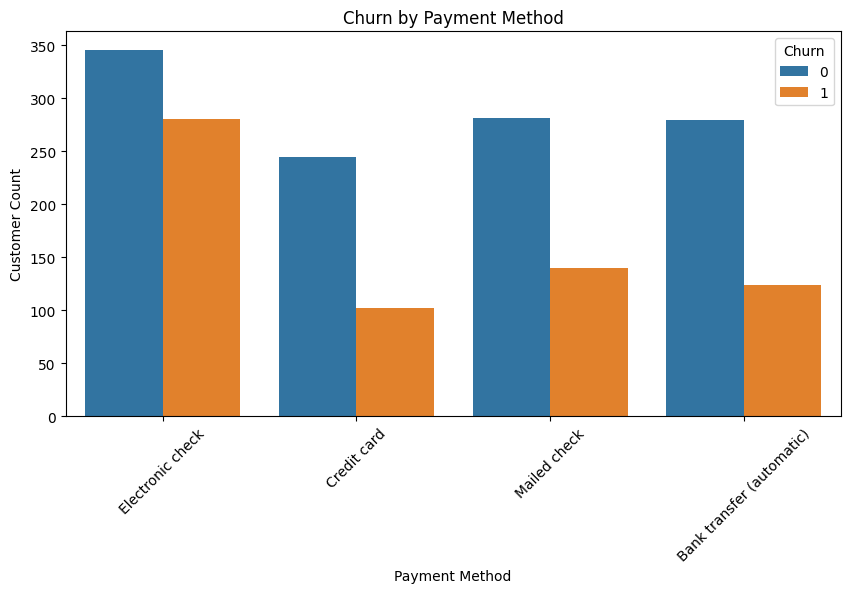

In [37]:
# churn by payment method
plt.figure(figsize=(10,5))

# Reconstruct the 'PaymentMethod' column for plotting
def get_original_payment_method(row):
    if row['PaymentMethod_Credit card'] == 1:
        return 'Credit card'
    elif row['PaymentMethod_Electronic check'] == 1:
        return 'Electronic check'
    elif row['PaymentMethod_Mailed check'] == 1:
        return 'Mailed check'
    else:
        return 'Bank transfer (automatic)' # Assuming this is the dropped_first category

df['Original_PaymentMethod'] = df.apply(get_original_payment_method, axis=1)

sns.countplot(
    x='Original_PaymentMethod',
    hue='Churn',
    data=df
)

plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Customer Count')
plt.xticks(rotation=45)
plt.show()

# Drop the temporary 'Original_PaymentMethod' column if not needed further
df.drop('Original_PaymentMethod', axis=1, inplace=True)

Electronic check users may have higher churn rates than customers using automatic payment methods.

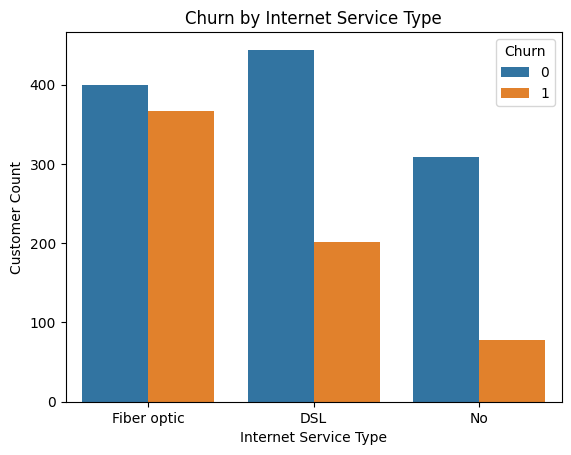

In [39]:
# churn by internet service

# Reconstruct the 'InternetService' column for plotting
def get_original_internet_service(row):
    if row['InternetService_Fiber optic'] == 1:
        return 'Fiber optic'
    elif row['InternetService_No'] == 1:
        return 'No'
    else:
        return 'DSL' # Assuming 'DSL' was the dropped_first category

df['Original_InternetService'] = df.apply(get_original_internet_service, axis=1)

sns.countplot(x='Original_InternetService', hue='Churn', data=df)
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service Type')
plt.ylabel('Customer Count')
plt.show()

# Drop the temporary 'Original_InternetService' column if not needed further
df.drop('Original_InternetService', axis=1, inplace=True)

Fiber optic internet customers may show higher churn due to pricing or service expectations.

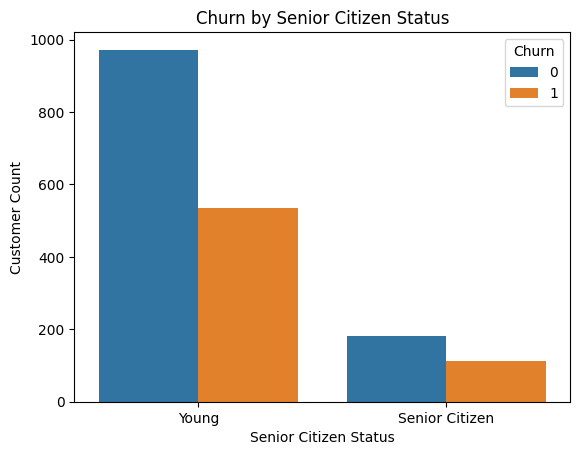

In [47]:
# churn by senior citizen status
sns.countplot(x='SeniorCitizen_1', hue='Churn', data=df)
plt.title('Churn by Senior Citizen Status')
plt.xlabel('Senior Citizen Status')
plt.ylabel('Customer Count')
plt.xticks(ticks=['0', '1'], labels=['Young' , 'Senior Citizen'])
plt.show()

Senior citizens may exhibit different churn behavior compared to younger customers.

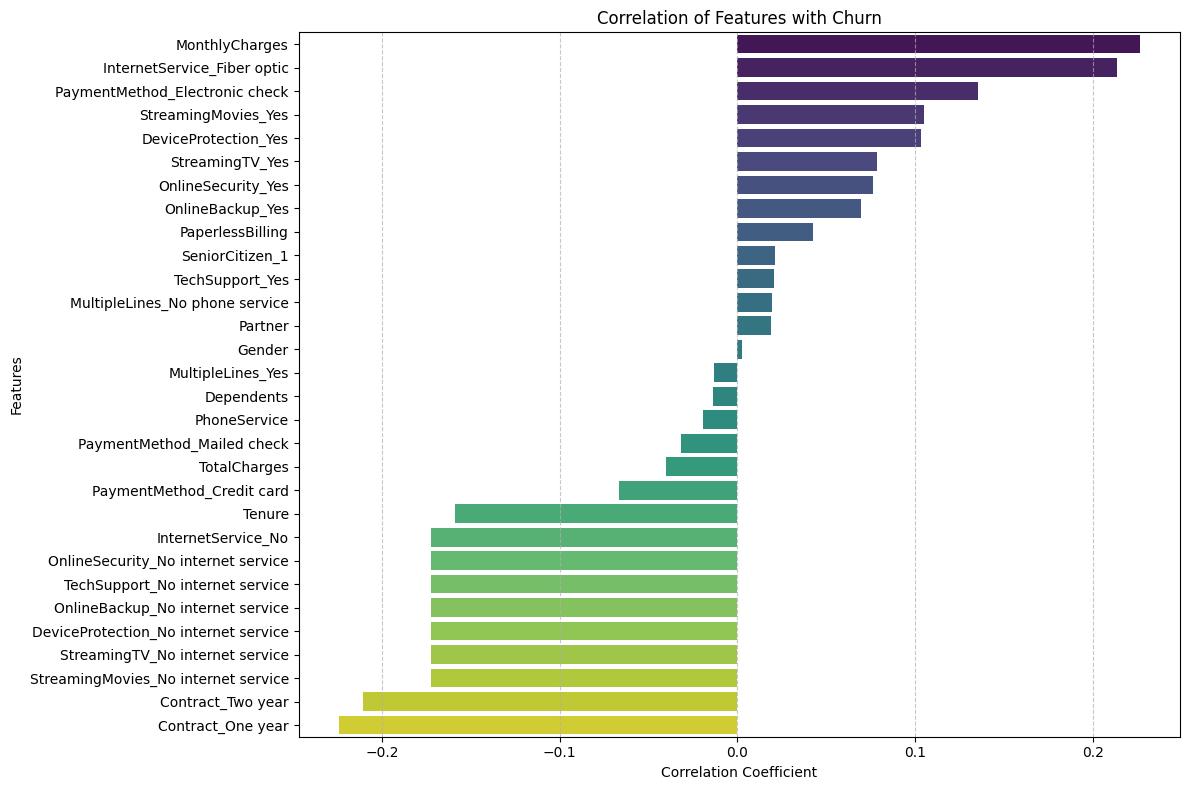

In [53]:
# relationship between tenure, charges and churn
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Get correlations with 'Churn'
churn_correlations = correlation_matrix['Churn'].sort_values(ascending=False)

# Drop the 'Churn' self-correlation for a cleaner plot
churn_correlations = churn_correlations.drop('Churn')

# Plot the correlations with Churn
plt.figure(figsize=(12, 8))
sns.barplot(x=churn_correlations.values, y=churn_correlations.index, palette='viridis')
plt.title('Correlation of Features with Churn')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This bar chart presents the correlation of each individual feature with the 'Churn' variable.

*   **Positive bars** indicate features that are positively correlated with churn, meaning as the value of these features increases, the likelihood of churn also tends to increase.
*   **Negative bars** indicate features that are negatively correlated with churn, meaning as the value of these features increases, the likelihood of churn tends to decrease.

This provides a direct and easy-to-understand view of which factors are most strongly associated with customer churn in your dataset.

# **Model Building , Training and Evaluation**

**### 1. Logistic Regression Model**

In [54]:
# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42)

# Train the model
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


**### Evaluation of Logistic Regression Model**

Accuracy: 0.7028

Confusion Matrix:
[[181  49]
 [ 58  72]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.79      0.77       230
           1       0.60      0.55      0.57       130

    accuracy                           0.70       360
   macro avg       0.68      0.67      0.67       360
weighted avg       0.70      0.70      0.70       360



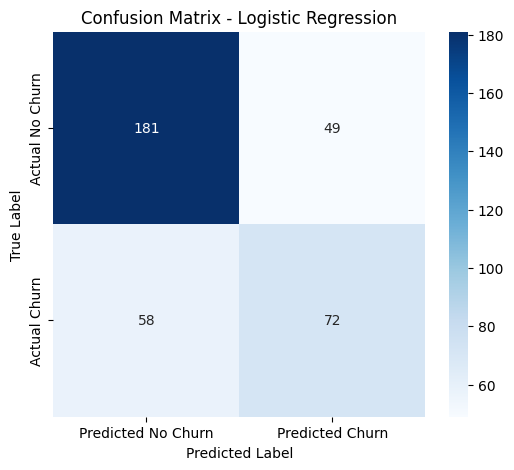

In [55]:
# Calculate accuracy
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"Accuracy: {accuracy_log_reg:.4f}")

# Display confusion matrix
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
print("\nConfusion Matrix:")
print(cm_log_reg)

# Display classification report
report_log_reg = classification_report(y_test, y_pred_log_reg)
print("\nClassification Report:")
print(report_log_reg)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

The Logistic Regression model has been trained and evaluated. The accuracy, confusion matrix, and classification report provide insights into its performance. We can see the number of true positives, true negatives, false positives, and false negatives from the confusion matrix, and precision, recall, and F1-score from the classification report.

**### 2. Decision Tree Classifier**


In [56]:
# Initialize the Decision Tree Classifier model
dec_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
dec_tree_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dec_tree = dec_tree_model.predict(X_test)

print("Decision Tree Classifier Model Trained Successfully!")

Decision Tree Classifier Model Trained Successfully!


**### Evaluation of Decision Tree Classifier**

Accuracy: 0.5972

Confusion Matrix:
[[151  79]
 [ 66  64]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.66      0.68       230
           1       0.45      0.49      0.47       130

    accuracy                           0.60       360
   macro avg       0.57      0.57      0.57       360
weighted avg       0.61      0.60      0.60       360



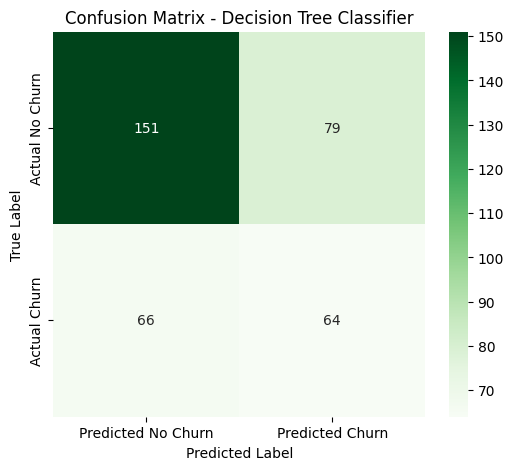

In [57]:
# Calculate accuracy
accuracy_dec_tree = accuracy_score(y_test, y_pred_dec_tree)
print(f"Accuracy: {accuracy_dec_tree:.4f}")

# Display confusion matrix
cm_dec_tree = confusion_matrix(y_test, y_pred_dec_tree)
print("\nConfusion Matrix:")
print(cm_dec_tree)

# Display classification report
report_dec_tree = classification_report(y_test, y_pred_dec_tree)
print("\nClassification Report:")
print(report_dec_tree)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dec_tree, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.show()

The Decision Tree Classifier model has also been trained and evaluated. Similar to Logistic Regression, we can analyze its performance metrics through the accuracy, confusion matrix, and classification report.

# **CHURN RISK INTERPRETATION**

### Impact of Features on Churn (Model Coefficients Table)

This table shows the features that have the strongest influence on churn, sorted by the absolute value of their Logistic Regression coefficients. A positive coefficient means the feature increases churn probability, while a negative coefficient decreases it.

In [62]:
# Get coefficients from the Logistic Regression model
coefficients = log_reg_model.coef_[0]

# Create a DataFrame for feature importance
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})

# Calculate absolute coefficient values for sorting
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])

# Sort by absolute coefficient value in descending order
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

# Display the top 15 most impactful features based on absolute coefficient value
display(coef_df.head(15).style.background_gradient(cmap='RdBu_r', subset=['Coefficient']))

,Feature,Coefficient,Abs_Coefficient
26,Contract_Two year,-2.323383,2.323383
25,Contract_One year,-1.871410,1.871410
3,Tenure,-0.754384,0.754384
11,InternetService_Fiber optic,0.617799,0.617799
28,PaymentMethod_Electronic check,0.588917,0.588917
20,TechSupport_Yes,-0.518563,0.518563
6,MonthlyCharges,0.304177,0.304177
7,TotalCharges,0.213558,0.213558
16,OnlineBackup_Yes,-0.198942,0.198942
5,PaperlessBilling,0.162711,0.162711


### Visualization of Feature Impact on Churn

This bar chart visually represents the impact of the top features on customer churn. Features with positive coefficients push customers towards churning, while those with negative coefficients indicate a lower likelihood of churn.

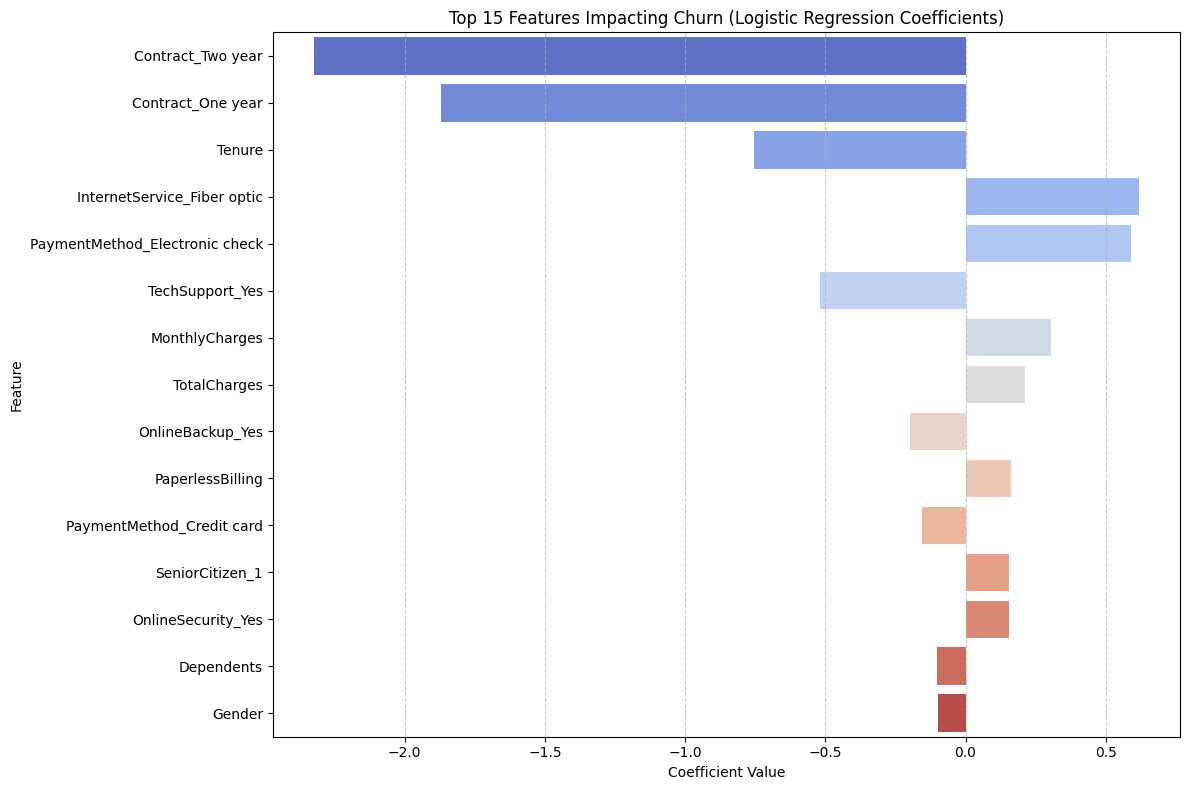

In [64]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=coef_df.head(15), palette='coolwarm')
plt.title('Top 15 Features Impacting Churn (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Detailed Interpretation of Churn Risk Profiles

Based on the Logistic Regression model's coefficients and our prior Exploratory Data Analysis, we can define customer risk profiles as follows:

#### **High-Risk Customers**
These customers possess characteristics that significantly increase their likelihood of churning. They often exhibit one or more of the following:

*   **Month-to-month contracts:** This is by far the strongest predictor of churn. Customers on flexible, short-term agreements are much more likely to leave.
*   **Short tenure:** Newer customers, or those with very few months of service, have not yet built loyalty and are prone to early departure.
*   **High monthly charges:** Customers paying higher monthly bills may feel they are not getting enough value or are more sensitive to pricing, leading them to seek alternatives.
*   **Electronic check payment method:** This payment method is associated with higher churn, possibly due to a lack of commitment compared to automatic payment options or issues with managing manual payments.
*   **Fiber optic internet service:** While a premium service, it also has a positive correlation with churn, which could indicate issues with service quality, higher expectations, or increased cost sensitivity among these users.
*   **Lack of value-added services (e.g., no Online Security, no Tech Support):** Customers who do not opt for these protective or support services are more vulnerable to problems and less integrated with the service ecosystem.

**Example High-Risk Customer:** A new customer (short tenure) on a month-to-month contract with fiber optic internet, high monthly charges, and pays via electronic check, without any additional security or tech support services.

#### **Medium-Risk Customers**
These customers display a mix of high-risk and low-risk characteristics, or their individual risk factors are not as pronounced. They might have:

*   Moderate tenure (e.g., 1-2 years).
*   One-year contracts (less risky than month-to-month, but more than two-year).
*   Average monthly charges.
*   Some value-added services, but not a comprehensive set.
*   Payment methods like mailed check, which are not as stable as credit card but less volatile than electronic check.

**Example Medium-Risk Customer:** A customer with 15 months of tenure, on a one-year contract, uses DSL internet, has moderate monthly charges, and has Online Backup but no Tech Support.

#### **Low-Risk Customers**
These customers possess characteristics that strongly correlate with loyalty and a low propensity to churn. They typically have:

*   **Long tenure:** Customers who have been with the company for several years have demonstrated strong loyalty.
*   **Two-year contracts:** This is the strongest indicator of loyalty, showing a commitment to the service.
*   **Low monthly charges:** Budget-conscious customers receiving good value for their money are less likely to seek alternatives.
*   **Automatic payment methods (Credit card, Bank transfer):** These indicate stability and convenience, often reducing churn.
*   **Multiple value-added services (e.g., Online Security, Tech Support, Device Protection):** Customers using these services are deeply integrated and likely satisfied with their overall service package.

**Example Low-Risk Customer:** A long-term customer (e.g., 5+ years tenure) on a two-year contract, uses credit card for automatic payments, has low monthly charges, and subscribes to Online Security, Tech Support, and Device Protection.

Understanding these profiles is crucial for developing targeted retention strategies. High-risk customers require immediate and aggressive interventions, medium-risk customers might benefit from proactive engagement and upselling valuable services, while low-risk customers are candidates for loyalty programs and continued excellent service.